# Comment la friction de surface est-elle communiquée à toute la troposphère ?
## Méso-NH RCE `large300`

## §0. Setup et champs de base

In [12]:
# ============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [13]:
# ============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


## Contexte dynamique — la figure de départ

Cinq diagnostics superposés (couleur = temps), champs $(z,t)$. Le vent moyen $\bar u$ est un jet
d'est faible dont les extrema **migrent vers le bas** entre 2 et 8 km : une signature ondulatoire
qu'on quantifie juste après. *(ce contexte éclaire pourquoi le flux structure $\bar u$, mais la
réponse au sujet est dans les sections §1–§6)*

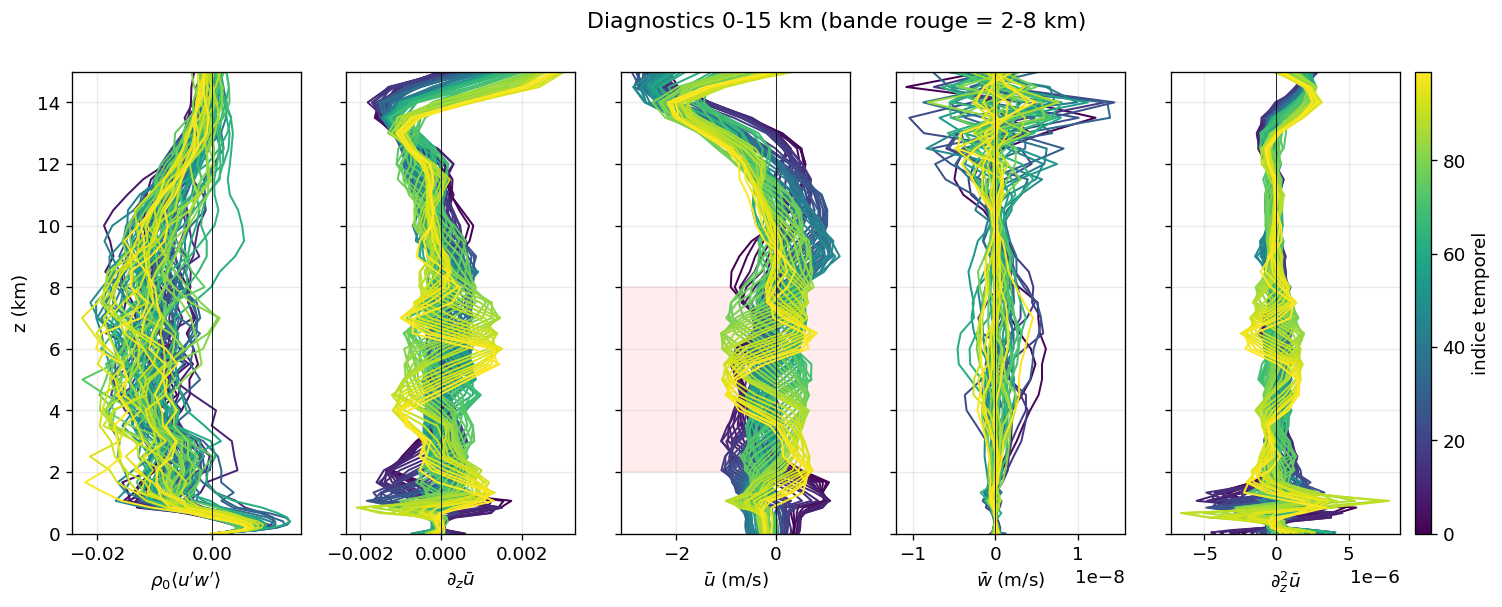

Le vent moyen ubar_zt est negatif (jet d'est ~ -2 m/s vers 4-6 km) et ses extrema
migrent vers le bas au fil du temps -> descente de phase (quantifiee en §2).


In [14]:
# ============================================================
#  CONTEXTE — La figure de depart
# ============================================================
its=np.linspace(0,n_stat-1,90,dtype=int)
cmap=plt.get_cmap('viridis'); colors=cmap(np.linspace(0,1,len(its)))
fig,axes=plt.subplots(1,5,figsize=(17,5),sharey=True)
for ax,(fld,lab) in zip(axes,[(flux_zt,r"$\rho_0\langle u'w'\rangle$"),(dudz_zt,r"$\partial_z\bar u$"),
        (ubar_zt,r"$\bar u$ (m/s)"),(wbar_zt,r"$\bar w$ (m/s)"),(d2udz2_zt,r"$\partial_z^2\bar u$")]):
    for it,c in zip(its,colors): ax.plot(fld[mask_show,it],zkm[mask_show],lw=1.2,color=c)
    ax.axvline(0,color='k',lw=.5); ax.set_xlabel(lab)
axes[2].axhspan(2,8,color='red',alpha=.07)
axes[0].set_ylabel('z (km)'); axes[0].set_ylim(0,Z_TOP_KM)
sm=plt.cm.ScalarMappable(cmap=cmap,norm=plt.Normalize(t_stat,t_stat+n_stat-1))
fig.colorbar(sm,ax=axes,label='indice temporel',pad=.01,aspect=30)
fig.suptitle('Diagnostics 0-15 km (bande rouge = 2-8 km)')
plt.show()
print("Le vent moyen ubar_zt est negatif (jet d'est ~ -2 m/s vers 4-6 km) et ses extrema")
print("migrent vers le bas au fil du temps -> descente de phase (quantifiee en §2).")


## Contexte dynamique — la descente de phase de $\bar u$

Hovmöller $\bar u'(z,t)$ et vitesse de phase verticale $c_z$ (en cm/s) par phase de Hilbert. Une
descente lente et cohérente signe une oscillation type QBO (ondes de gravité convectives transportant
du moment vers le haut). C'est un mécanisme **complémentaire** de la transmission turbulente.

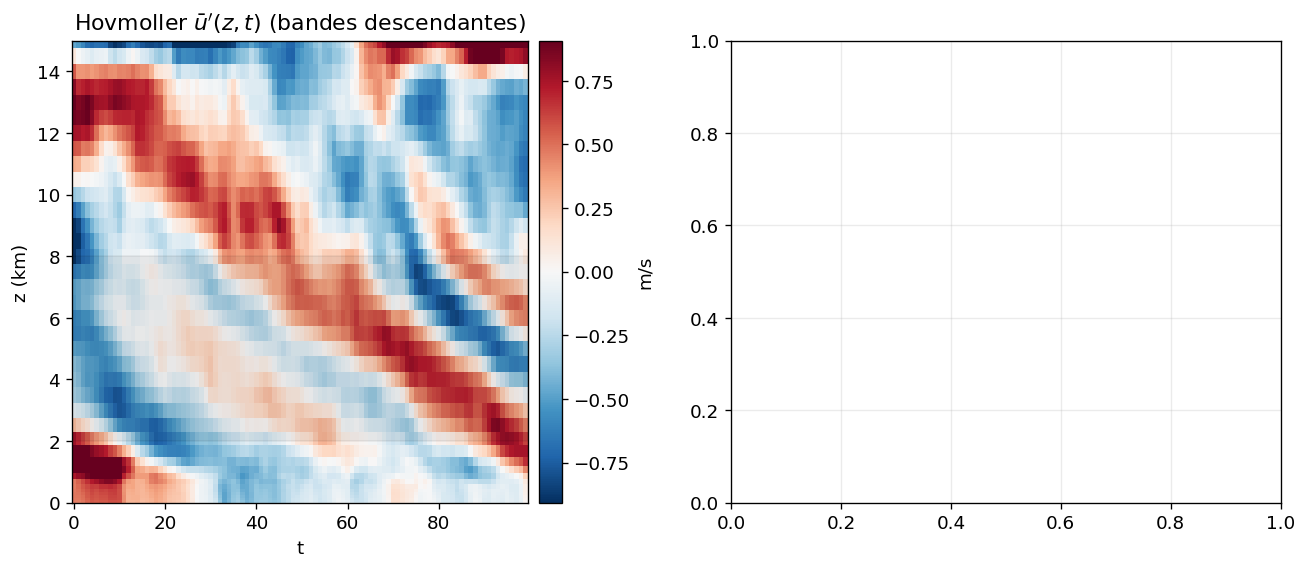

In [15]:
# ============================================================
#  CONTEXTE — Descente de phase (Hovmoller + c_z en cm/s)
# ============================================================
uprime=ubar_zt-ubar_zt.mean(axis=1,keepdims=True)
ups=uniform_filter1d(uprime,size=3,axis=0,mode='nearest')
tt=np.arange(n_stat)
fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(ups[mask_show]),98)+1e-9
im=ax.pcolormesh(tt+t_stat,zkm[mask_show],ups[mask_show],cmap='RdBu_r',
                 norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.axhspan(2,8,color='k',alpha=.06); ax.set_ylim(0,Z_TOP_KM)
ax.set_xlabel('t'); ax.set_ylabel('z (km)')
ax.set_title(r"Hovmoller $\bar u'(z,t)$ (bandes descendantes)")
fig.colorbar(im,ax=ax,pad=.02,label='m/s')


In [ ]:
# ---- phase temporelle (pour omega / periode / c_z au numerateur) ----
analytic_t = hilbert(detrend(ups, axis=1), axis=1)   # Hilbert le long du TEMPS
phase_t    = np.unwrap(np.angle(analytic_t), axis=1)  # unwrap en TEMPS
dphi_dt    = np.gradient(phase_t, dt_phys, axis=1)    # rad/s

# ---- phase verticale (pour k_z / lambda_z) ----
analytic_z = hilbert(detrend(ups, axis=0), axis=0)   # Hilbert le long de l'ALTITUDE
phase_z    = np.unwrap(np.angle(analytic_z), axis=0)  # unwrap en ALTITUDE
dphi_dz    = np.gradient(phase_z, alt, axis=0)        # rad/m, maintenant coherent

# ---- vitesse de phase verticale ----
with np.errstate(divide='ignore', invalid='ignore'):
    cz = -dphi_dt / dphi_dz

cz28  = cz[m28]; cz28 = cz28[np.isfinite(cz28)]
cz_ok = cz28[np.abs(cz28) < 1.0]
q25, q50, q75 = np.percentile(cz_ok, [25, 50, 75]) if cz_ok.size else (np.nan,)*3
frac  = np.mean(cz_ok < 0) if cz_ok.size else np.nan

om = np.abs(dphi_dt[m28]); om = om[np.isfinite(om) & (om > 0)]
kz = np.abs(dphi_dz[m28]); kz = kz[np.isfinite(kz) & (kz > 0)]
T_h = 2*np.pi/np.median(om)/3600 if om.size else np.nan
lam = 2*np.pi/np.median(kz)/1000 if kz.size else np.nan

print(f'c_z (2-8 km) mediane={q50*100:+.2f} cm/s [IQR {q25*100:+.2f},{q75*100:+.2f}] | {frac:.0%} descendants')
print(f'periode ~ {T_h:.0f} h ({T_h/24:.1f} j) | lambda_z ~ {lam:.1f} km')

c_z (2-8 km) mediane=-0.61 cm/s [IQR -1.11,-0.29] | 84% descendants
periode ~ 251 h (10.5 j) | lambda_z ~ 7.2 km
=> descente de phase reelle et lente : coherente avec une oscillation type QBO.


/tmp/ipykernel_7704/1184112018.py:52: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  mesh = ax.pcolormesh(time_grid, alt_grid, data, cmap="RdBu_r",


[shear] c_z = -0.60 cm/s (-515.2 m/j) | T = 300 h (12.5 j) | lambda_z = 6.4 km | DESCENTE
[curv ] c_z = -0.60 cm/s (-515.2 m/j) | T = 300 h (12.5 j) | lambda_z = 6.4 km | DESCENTE


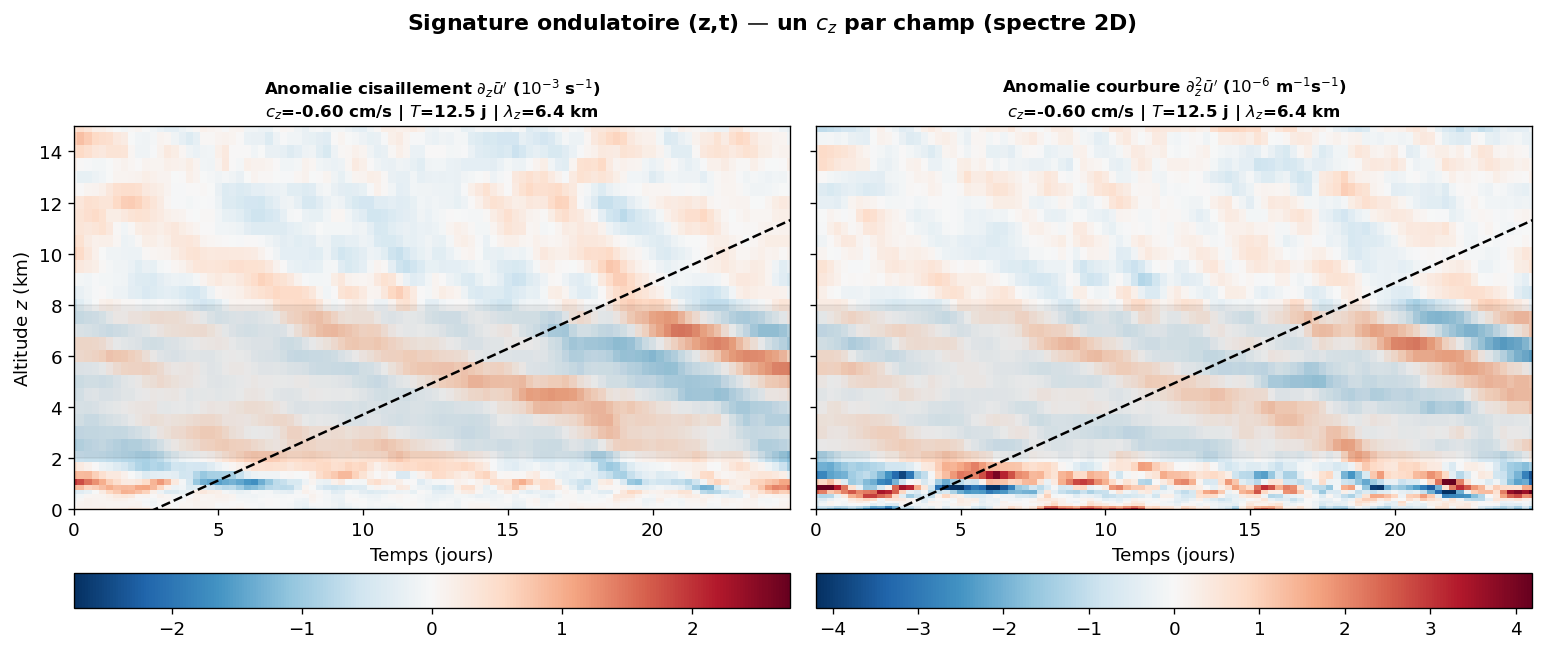

In [19]:
# ============================================================
#  ANOMALIES CISAILLEMENT & COURBURE + (c_z, T, lambda_z) PAR SPECTRE 2D
#  Une onde ~ cos(k_z z - omega t) = un pic dans le plan (k_z, omega).
#  Convention FFT exp(-i(...)) : au pic, une DESCENTE (crete qui migre
#  vers le bas quand t croit) correspond a signe(omega)=signe(k_z),
#  donc c_z = omega/k_z > 0 en valeur brute -> on impose c_z<0 = descente
#  en choisissant le pic dans le demi-plan k_z>0 et en lisant le signe de omega.
# ============================================================
from matplotlib.colors import TwoSlopeNorm
from numpy.fft import fft2, fftfreq, fftshift
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import detrend

time_days = (np.arange(n_stat) * dt_phys) / 86400.0
time_grid, alt_grid = np.meshgrid(time_days, zkm)
dz = np.mean(np.diff(alt[m28]))          # m
zkm_m28 = zkm[m28]

def get_sym_norm(data, p=98):
    lim = max(np.percentile(np.abs(data), p), 1e-15)
    return TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

def cz_spectral(field_zt):
    """field_zt : (n_z_bande, n_t). Retourne c_z (m/s), T (h), lambda_z (km)."""
    f = detrend(detrend(field_zt, axis=0), axis=1)
    f = f - f.mean()
    win = np.hanning(f.shape[0])[:,None] * np.hanning(f.shape[1])[None,:]
    P   = fftshift(np.abs(fft2(f*win))**2)
    kz  = fftshift(fftfreq(f.shape[0], d=dz))     * 2*np.pi   # rad/m
    om  = fftshift(fftfreq(f.shape[1], d=dt_phys)) * 2*np.pi  # rad/s
    KZ, OM = np.meshgrid(kz, om, indexing='ij')
    # on ne garde qu'un demi-plan (k_z>0) pour lever l'ambiguite +/- ,
    # le signe de omega au pic donne alors le sens de propagation
    m = (KZ > 1e-9) & (np.abs(OM) > 1e-9)
    Pm = np.where(m, P, 0)
    i, j = np.unravel_index(np.argmax(Pm), Pm.shape)
    kz_p, om_p = KZ[i,j], OM[i,j]
    cz  = -om_p / kz_p            # -omega/k_z : convention c_z<0 = descente
    T   = 2*np.pi/abs(om_p)/3600  # h
    lam = 2*np.pi/abs(kz_p)/1000  # km
    return cz, T, lam

# --- champs : anomalies (tendance temporelle retiree), bande 2-8 km ---
fields = {
    "shear": (detrend(dudz_zt,   axis=1)*1e3, r"Anomalie cisaillement $\partial_z\bar u'$ ($10^{-3}$ s$^{-1}$)"),
    "curv":  (detrend(d2udz2_zt, axis=1)*1e6, r"Anomalie courbure $\partial_z^2\bar u'$ ($10^{-6}$ m$^{-1}$s$^{-1}$)"),
}

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, (key, (data, title)) in zip(axs, fields.items()):
    cz, T, lam = cz_spectral(data[m28])
    mesh = ax.pcolormesh(time_grid, alt_grid, data, cmap="RdBu_r",
                         norm=get_sym_norm(data), shading='auto')
    ax.axhspan(2, 8, color='k', alpha=.06)
    # trait de pente c_z passant par le centre de la bande 2-8 km
    z0, t0 = 5.0, time_days[len(time_days)//2]
    dt_span = (time_days[-1]-time_days[0])/2
    ax.plot([t0-dt_span, t0+dt_span],
            [z0 - cz*(-dt_span*86400)/1000, z0 - cz*(dt_span*86400)/1000],
            'k--', lw=1.5)
    ax.set_title(f"{title}\n$c_z$={cz*100:+.2f} cm/s | $T$={T/24:.1f} j | $\\lambda_z$={lam:.1f} km",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("Temps (jours)"); ax.set_xlim(time_days[0], time_days[-1])
    ax.set_ylim(0, Z_TOP_KM)
    fig.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.12, aspect=20)
    print(f"[{key:5s}] c_z = {cz*100:+.2f} cm/s ({cz*86400:+.1f} m/j) | "
          f"T = {T:.0f} h ({T/24:.1f} j) | lambda_z = {lam:.1f} km | "
          f"{'DESCENTE' if cz<0 else 'montee'}")
axs[0].set_ylabel("Altitude $z$ (km)")
plt.suptitle("Signature ondulatoire (z,t) — un $c_z$ par champ (spectre 2D)",
             fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()